In [1]:
import sys
sys.path.append("/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/")
from skew_correction import full_correction

import numpy as np
import os 
import sys
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
import concurrent
import concurrent.futures
from astropy.visualization import ImageNormalize, AsinhStretch
from juanfit import gaussian
from plotting_modules import doppler_plot, amplitude_plot
from skew_parameter_search import detrend_dopp
from fancy_colorbar import plot_colorbar

from matplotlib.animation import FuncAnimation
from astropy.visualization import (ImageNormalize, AsinhStretch,
                                   ) 
from IPython.display import HTML, display

In [38]:
import saffron
from saffron.utils import Preclean
from saffron.utils.despike import despike_4D
from saffron.utils.denoise import denoise_data

In [61]:
spice_file = "~/work/spice_psf/spice_data/solo_L2_spice-n-ras_20231026T105531_V22_218104178-000.fits"

with fits.open(spice_file) as hdul:
    hdul.info()
    spice_NeVIII_data = hdul[2].data[:, 16:-8, :, :].copy()
    spice_NeVIII_header = hdul[2].header.copy()
    # spice_CIII_data = hdul[4].data[0].copy()
    # spice_CIII_header = hdul[4].header.copy()

spice_NeVIII_header["NAXIS3"] = spice_NeVIII_header["NAXIS3"] - 24
spice_NeVIII_header["CRVAL3"] = spice_NeVIII_header["CRVAL3"] + spice_NeVIII_header["CDELT3"] * 16

spice_NeVIII_data = Preclean(spice_NeVIII_data.astype(float).copy())
spice_NeVIII_data = despike_4D(
    spice_NeVIII_data.copy(),
)
spice_NeVIII_data = denoise_data(spice_NeVIII_data.copy()[0,:,:,:], [6, 2, 1, 0, 0])
spice_NeVIII_data = spice_NeVIII_data.T
# spice_CIII_data = spice_CIII_data.T



Filename: /cluster/home/zhuyin/work/spice_psf/spice_data/solo_L2_spice-n-ras_20231026T105531_V22_218104178-000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  O III 703 binned (Merged)    1 PrimaryHDU     428   (160, 830, 56, 1)   float32   
  1  S IV (Merged)    1 ImageHDU       427   (160, 830, 40, 1)   float32   
  2  N IV 765 ... Ne VIII 770 (Merged)    1 ImageHDU       427   (160, 830, 72, 1)   float32   
  3  SV 786+O IV 787 + S V 786+O IV 787 (Merged)    1 ImageHDU       429   (160, 830, 40, 1)   float32   
  4  Ly Gamma 972 - Peak    1 ImageHDU       420   (160, 830, 18, 1)   float32   
  5  N III 991 (Merged)    1 ImageHDU       427   (160, 830, 59, 1)   float32   
  6  VARIABLE_KEYWORDS    1 BinTableHDU    385   1R x 27C   [160D, 160I, 160I, 160I, 160I, 160I, 160E, 160E, 160E, 160E, 5I, 5I, 5I, 5I, 5J, 5J, 5J, 5J, 3680A, 160D, 160D, 56D, 40D, 72D, 40D, 18D, 59D]   
  7  WCSDVARR      1 ImageHDU        28   (160,)   float64   
  8  WCSDVARR      2 Image

In [6]:
spice_NeVIII_data.shape#, spice_CIII_data.shape

(160, 830, 72)

In [62]:
NeVIII_wvl = spice_NeVIII_header["CRVAL3"] + \
spice_NeVIII_header["CDELT3"] * (np.arange(1, spice_NeVIII_header["NAXIS3"]+1) - spice_NeVIII_header["CRPIX3"])
NeVIII_wvl = NeVIII_wvl*10
# CIII_wvl = spice_CIII_header["CRVAL3"] + \
# spice_CIII_header["CDELT3"] * (np.arange(1, spice_CIII_header["NAXIS3"]+1) - spice_CIII_header["CRPIX3"])
# CIII_wvl = CIII_wvl*10

553


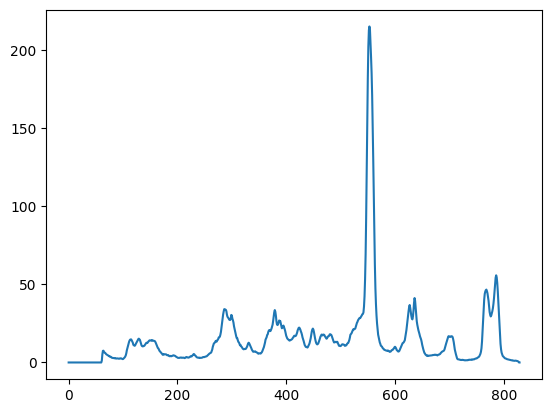

In [8]:
plt.plot(np.nansum(spice_NeVIII_data[11,:,:],axis=1))
print(np.argmax(np.nansum(spice_NeVIII_data[11,:,:],axis=1)))

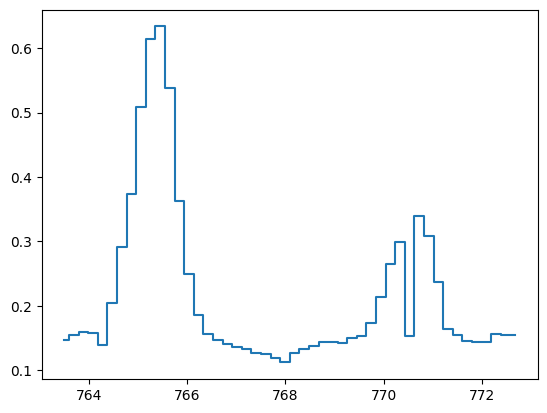

In [64]:
plt.step(NeVIII_wvl, spice_NeVIII_data[10, 369 + 119,:], where="mid")

In [14]:
load_data = False

In [8]:
# if not load_data:
#     raw_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, 0, 0, nthreads=12, linelist={'C III 977':977.0})
# else:
#     with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/raw_CIII_results.npz", allow_pickle=True) as f:
#         raw_results_CIII = dict(f)

In [65]:
if not load_data:
    raw_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, 0, 0, nthreads=12, 
    linelist={'N IV 765':765.1, 'Ne VIII 770':770.4})
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/raw_NeVIII_results_20231026T105531.npz", allow_pickle=True) as f:
        raw_results_NeVIII = dict(f)

In [66]:
def correction_preview(best_correction_results, load_data=load_data, line_index=0):
    if load_data:
        plt_linefits = best_correction_results['linefits'].item()
    else:
        plt_linefits = best_correction_results['linefits']
    ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
    line_name = list(plt_linefits[0].keys())[line_index]
    date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

    fig=plt.figure(figsize=[16,8])
    gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
    cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
    axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

    plt.suptitle('Corrected fits for '+line_name+' at '+date)
    amplitude_plot(plt_linefits[0][line_index],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax)
    doppler_plot(plt_linefits[0][line_index],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
    axes[1].set(title='Doppler; best xshift, yshift='+str(best_correction_results['xlshift'])+','+str(best_correction_results['ylshift']))

In [11]:
# correction_preview(raw_results_CIII)

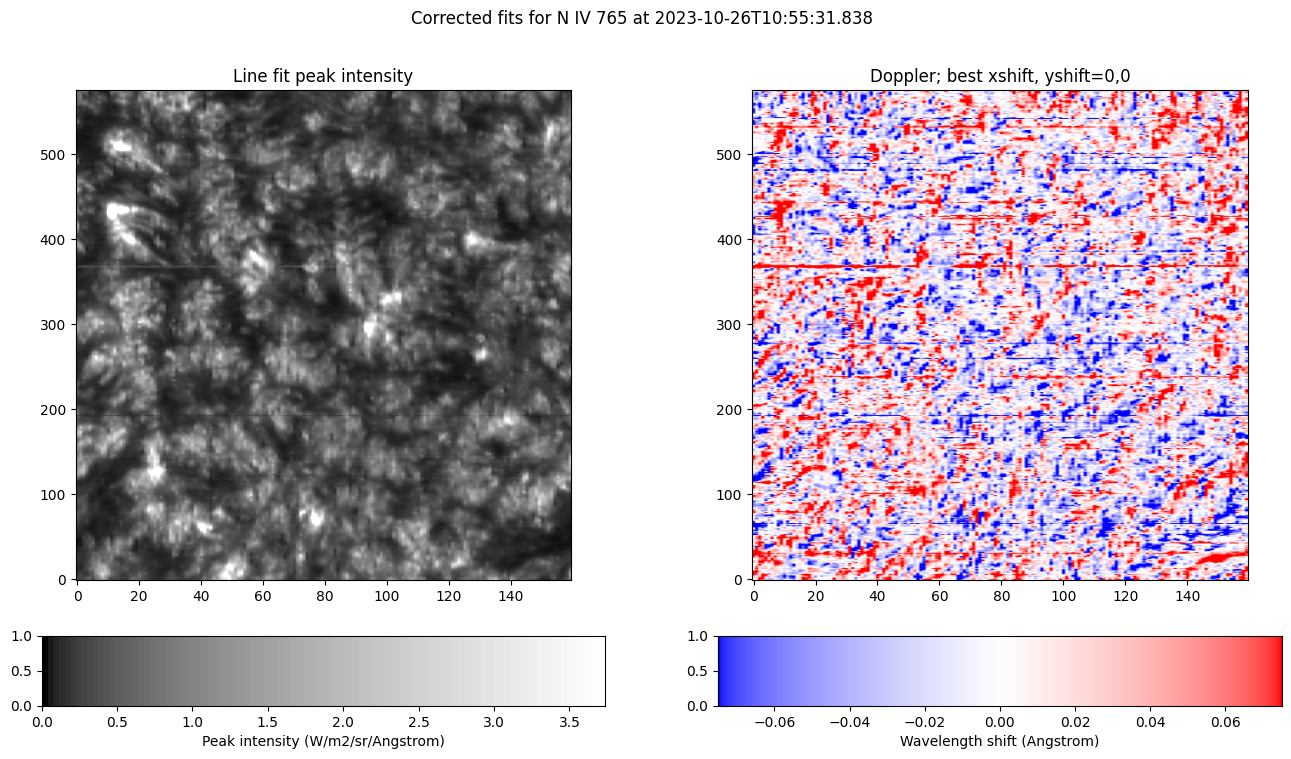

In [43]:
correction_preview(raw_results_NeVIII)

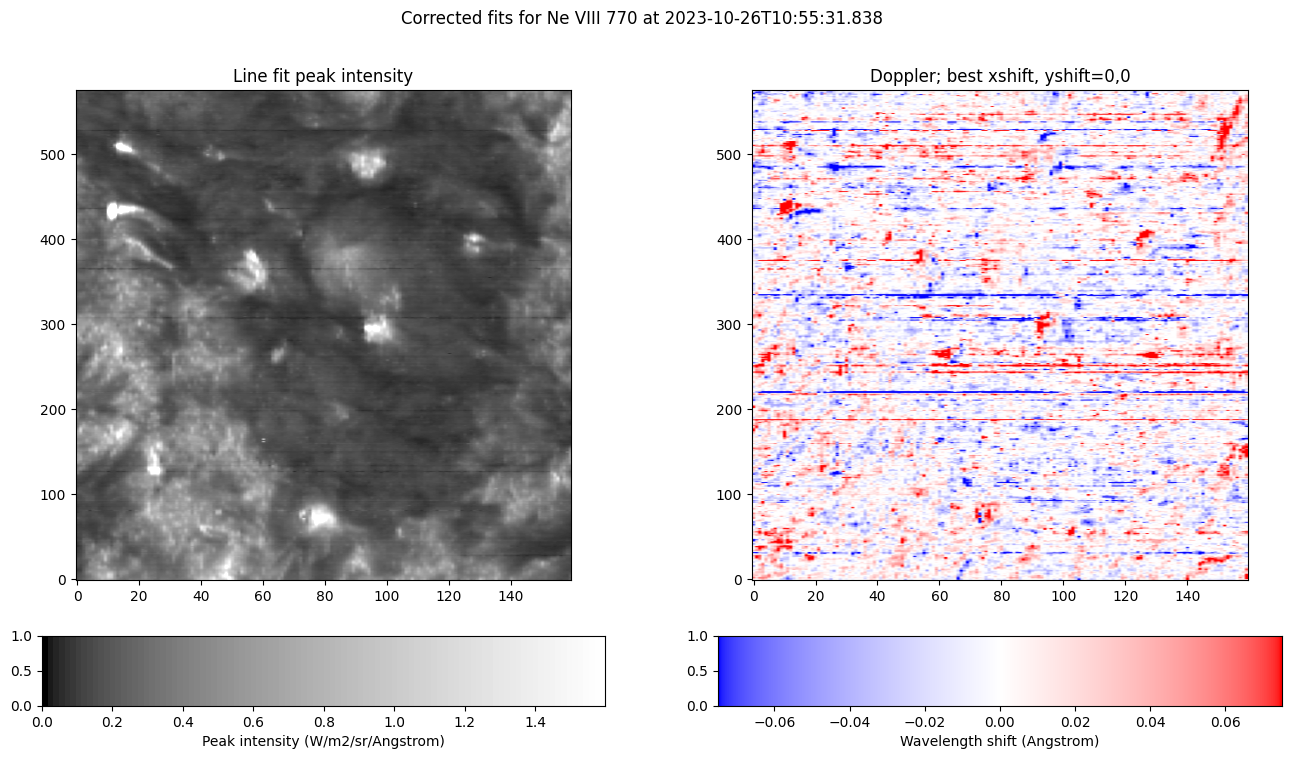

In [68]:
correction_preview(raw_results_NeVIII, line_index=1)

In [23]:
# best_skew_x_CIII, best_skew_y_CIII = 1.667, -1.667

# if False:
#     best_correction_results_CIII = full_correction(spice_CIII_data, spice_CIII_header, best_skew_x_CIII, best_skew_y_CIII, nthreads=12,
#                                                linelist={'C III 977':977.0})
# else:
#     with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/best_CIII_results.npz", allow_pickle=True) as f:
#         best_correction_results_CIII = dict(f)

In [15]:
# correction_preview(best_correction_results_CIII)

In [69]:
best_skew_x_NeVIII, best_skew_y_NeVIII = 1.3333, -1.3333

if not load_data:
    best_correction_results_NeVIII = full_correction(spice_NeVIII_data, spice_NeVIII_header, best_skew_x_NeVIII, best_skew_y_NeVIII, nthreads=12,
                                                linelist={'N IV 765':765.1, 'Ne VIII 770':770.4})
else:
    with np.load("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/best_NeVIII_results_20231026T105531.npz", allow_pickle=True) as f:
        best_correction_results_NeVIII = dict(f)

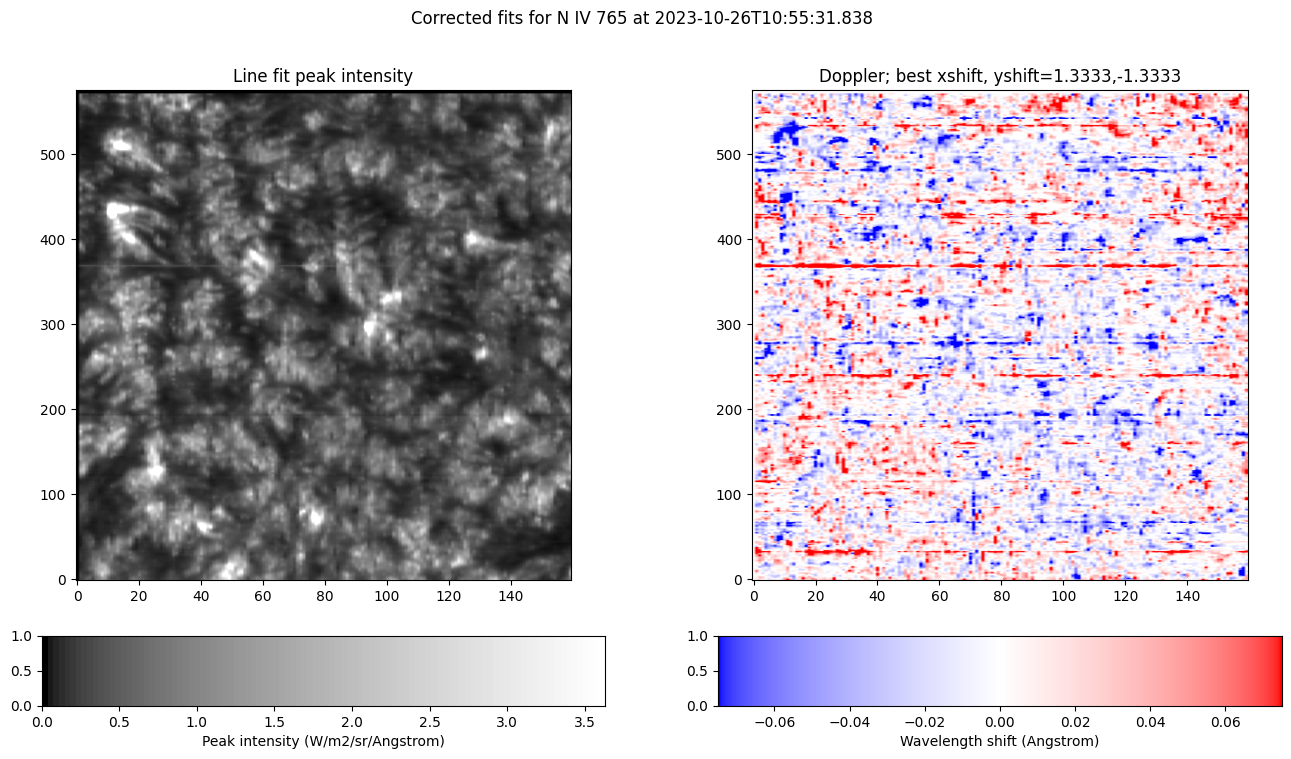

In [70]:
correction_preview(best_correction_results_NeVIII)

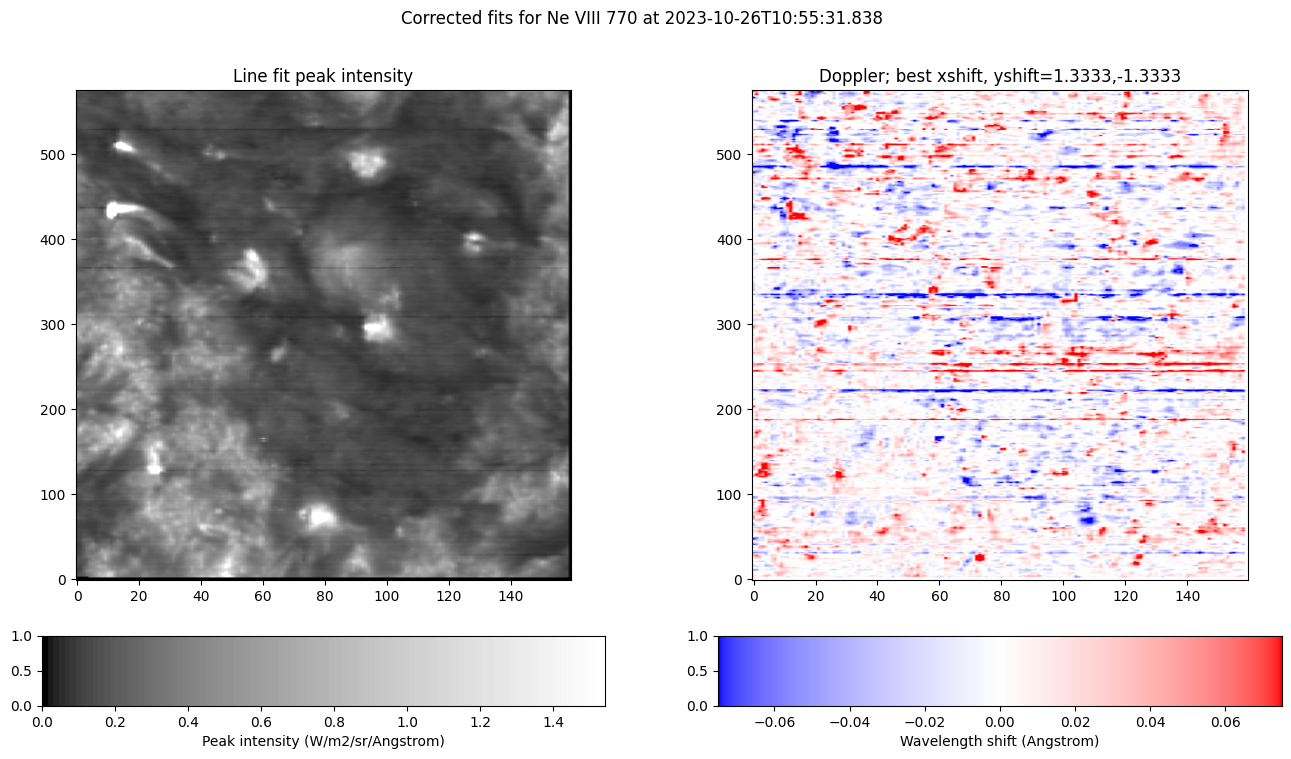

In [71]:
correction_preview(best_correction_results_NeVIII, line_index=1)

In [72]:
if not load_data:
    # np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/raw_CIII_results.npz", **raw_results_CIII)
    np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/raw_NeVIII_results_20231026T105531.npz", **raw_results_NeVIII)
    # np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/best_CIII_results.npz", **best_correction_results_CIII)
    np.savez("/cluster/home/zhuyin/work/spice_psf/spice_skew_20231026/best_NeVIII_results.npz_20231026T105531", **best_correction_results_NeVIII)

In [55]:
# if not load_data:
#     raw_CIII_int = raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
#     raw_CIII_vel = detrend_dopp(raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
#     raw_CIII_vel_err = raw_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T


#     skew_CIII_int = best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['amplitudes'].data[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T
#     skew_CIII_vel = detrend_dopp(best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'])[:,raw_results_CIII['ymin']:raw_results_CIII['ymax']].T
#     skew_CIII_vel_err = best_correction_results_CIII['linefits']['C III 977 - Peak']['C III 977']['centers'].uncertainty.array[:,raw_results_CIII['ymin']:raw_results_CIII['ymax'],0,0].T

# else:
#     raw_CIII_linefits = raw_results_CIII['linefits'].item()
#     raw_results_CIII_ymin = raw_results_CIII['ymin'].item()
#     raw_results_CIII_ymax = raw_results_CIII['ymax'].item()

#     raw_CIII_int = raw_CIII_linefits[0][0]['amplitudes'].data[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T
#     raw_CIII_vel = detrend_dopp(raw_CIII_linefits[0][0]['centers'])[:,raw_results_CIII_ymin:raw_results_CIII_ymax].T
#     raw_CIII_vel_err = raw_CIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T

#     skew_CIII_linefits = best_correction_results_CIII['linefits'].item()

#     skew_CIII_int = skew_CIII_linefits[0][0]['amplitudes'].data[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T
#     skew_CIII_vel = detrend_dopp(skew_CIII_linefits[0][0]['centers'])[:,raw_results_CIII_ymin:raw_results_CIII_ymax].T
#     skew_CIII_vel_err = skew_CIII_linefits[0][0]['centers'].uncertainty.array[:,raw_results_CIII_ymin:raw_results_CIII_ymax,0,0].T    


# raw_CIII_vel_mask = np.abs(raw_CIII_vel_err) > 0.025
# raw_CIII_vel[raw_CIII_vel_mask] = np.nan
# raw_CIII_vel = raw_CIII_vel - np.nanmedian(raw_CIII_vel[330:350, :])
# raw_CIII_vel = raw_CIII_vel/977.020*const.c.to_value(u.km/u.s)

# skew_CIII_vel_mask = np.abs(skew_CIII_vel_err) > 0.025
# skew_CIII_vel[skew_CIII_vel_mask] = np.nan
# skew_CIII_vel = skew_CIII_vel - np.nanmedian(skew_CIII_vel[330:350, :])
# skew_CIII_vel = skew_CIII_vel/977.020*const.c.to_value(u.km/u.s)


In [41]:
# raw_results_CIII['dat_skew'].shape

(96, 836, 17)

In [27]:
# fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

# ax1.imshow(raw_CIII_int,
#            origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
#            norm=ImageNormalize(vmin=np.nanpercentile(raw_CIII_int, 0.5),
#                                vmax=np.nanpercentile(raw_CIII_int, 99.5),
#                                stretch=AsinhStretch(0.1)))

# im2 = ax2.imshow(raw_CIII_vel,
#            origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
#            norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

# ax3.imshow(skew_CIII_int,
#            origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
#            norm=ImageNormalize(vmin=np.nanpercentile(skew_CIII_int, 0.5),
#                                vmax=np.nanpercentile(skew_CIII_int, 99.5),
#                                stretch=AsinhStretch(0.1)))

# im4 = ax4.imshow(skew_CIII_vel,
#            origin="lower", aspect=spice_CIII_header['CDELT2']/spice_CIII_header['CDELT1'], interpolation='none',
#            norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

# ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
#         color="white")

# ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
#         color="white")

# clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

# fig.suptitle(spice_CIII_header['EXTNAME'] + " " +spice_CIII_header['DATE-BEG'], fontsize=12)

# for ax_ in (ax1,ax2):
#     ax_.axhline(330, color="grey", alpha=0.6, ls="--")
#     ax_.axhline(350, color="grey", alpha=0.6, ls="--")

# for ax_ in (ax3,ax4):
#     ax_.contour(skew_CIII_int, [np.nanpercentile(skew_CIII_int, 80)], linewidths=0.5, alpha=0.8, colors="black")



In [73]:
if not load_data:
    raw_NeVIII_int = raw_results_NeVIII['linefits'][0][1]['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
    raw_NeVIII_vel = detrend_dopp(raw_results_NeVIII['linefits'][0][1]['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
    raw_NeVIII_vel_err = raw_results_NeVIII['linefits'][0][1]['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T


    skew_NeVIII_int = best_correction_results_NeVIII['linefits'][0][1]['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
    skew_NeVIII_vel = detrend_dopp(best_correction_results_NeVIII['linefits'][0][1]['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
    skew_NeVIII_vel_err = best_correction_results_NeVIII['linefits'][0][1]['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
else:
    raw_NeVIII_linefits = raw_results_NeVIII['linefits'].item()
    raw_results_NeVIII_ymin = raw_results_NeVIII['ymin'].item()
    raw_results_NeVIII_ymax = raw_results_NeVIII['ymax'].item()

    raw_NeVIII_int = raw_NeVIII_linefits[0][1]['amplitudes'].data[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T
    raw_NeVIII_vel = detrend_dopp(raw_NeVIII_linefits[0][1]['centers'])[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax].T
    raw_NeVIII_vel_err = raw_NeVIII_linefits[0][1]['centers'].uncertainty.array[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T

    skew_NeVIII_linefits = best_correction_results_NeVIII['linefits'].item()

    skew_NeVIII_int = skew_NeVIII_linefits[0][1]['amplitudes'].data[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T
    skew_NeVIII_vel = detrend_dopp(skew_NeVIII_linefits[0][1]['centers'])[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax].T
    skew_NeVIII_vel_err = skew_NeVIII_linefits[0][1]['centers'].uncertainty.array[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T  
    

raw_NeVIII_vel_mask = np.abs(raw_NeVIII_vel_err) > 0.025
raw_NeVIII_vel[raw_NeVIII_vel_mask] = np.nan
raw_NeVIII_vel = raw_NeVIII_vel - np.nanmedian(raw_NeVIII_vel[:200, 0:50])
raw_NeVIII_vel = raw_NeVIII_vel/770.428*const.c.to_value(u.km/u.s)

skew_NeVIII_vel_mask = np.abs(skew_NeVIII_vel_err) > 0.025
skew_NeVIII_vel[skew_NeVIII_vel_mask] = np.nan
skew_NeVIII_vel = skew_NeVIII_vel - np.nanmedian(skew_NeVIII_vel[:200, 0:50])
skew_NeVIII_vel = skew_NeVIII_vel/770.428*const.c.to_value(u.km/u.s)

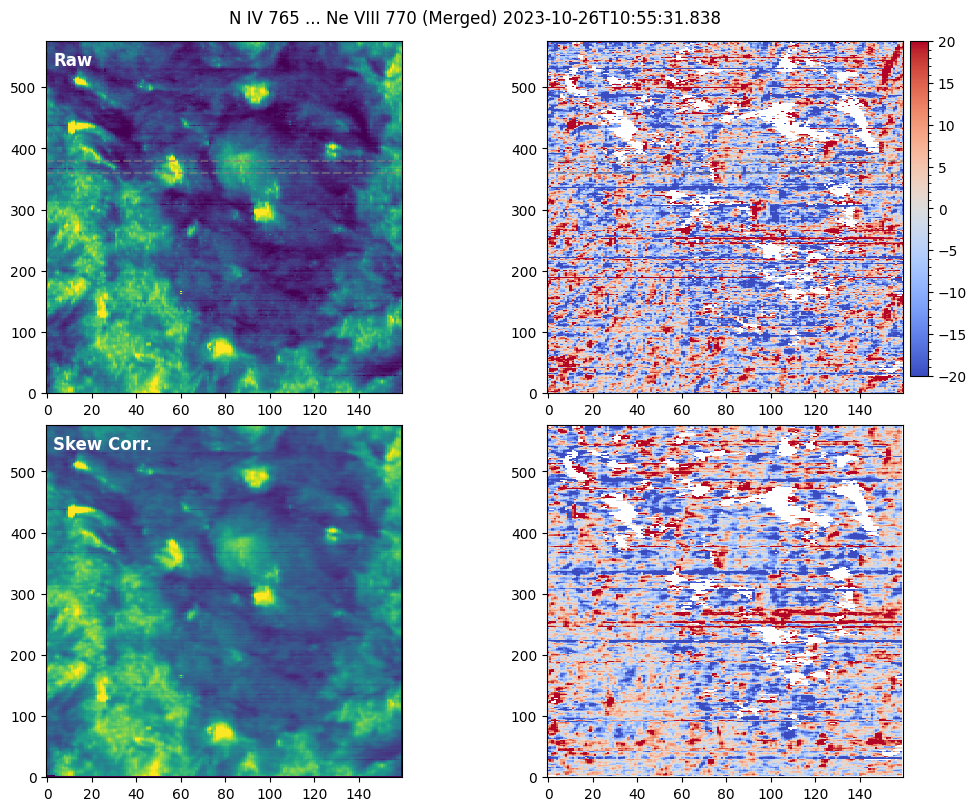

In [74]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

ax1.imshow(raw_NeVIII_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_NeVIII_int, 0.5),
                               vmax=np.nanpercentile(raw_NeVIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im2 = ax2.imshow(raw_NeVIII_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax3.imshow(skew_NeVIII_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_NeVIII_int, 0.5),
                               vmax=np.nanpercentile(skew_NeVIII_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im4 = ax4.imshow(skew_NeVIII_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

fig.suptitle(spice_NeVIII_header['EXTNAME'] + " " +spice_NeVIII_header['DATE-BEG'], fontsize=12)


for ax_ in (ax1,ax2):
    ax_.axhline(360, color="grey", alpha=0.6, ls="--")
    ax_.axhline(380, color="grey", alpha=0.6, ls="--")

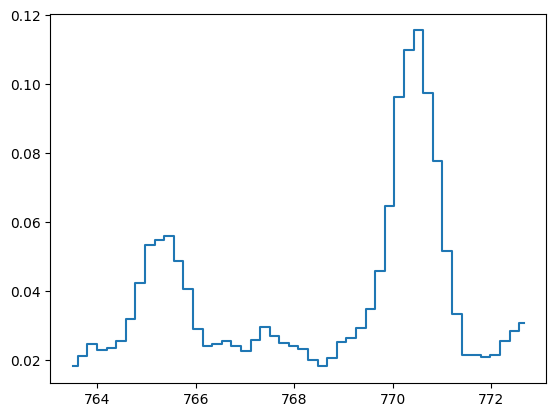

In [76]:
plt.step(NeVIII_wvl, spice_NeVIII_data[120, 357 + 1,:], where="mid")

In [77]:
if not load_data:
    raw_NIV_int = raw_results_NeVIII['linefits'][0][0]['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
    raw_NIV_vel = detrend_dopp(raw_results_NeVIII['linefits'][0][0]['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
    raw_NIV_vel_err = raw_results_NeVIII['linefits'][0][0]['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T


    skew_NIV_int = best_correction_results_NeVIII['linefits'][0][0]['amplitudes'].data[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
    skew_NIV_vel = detrend_dopp(best_correction_results_NeVIII['linefits'][0][0]['centers'])[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax']].T
    skew_NIV_vel_err = best_correction_results_NeVIII['linefits'][0][0]['centers'].uncertainty.array[:,raw_results_NeVIII['ymin']:raw_results_NeVIII['ymax'],0,0].T
else:
    raw_NIV_linefits = raw_results_NeVIII['linefits'].item()
    raw_results_NeVIII_ymin = raw_results_NeVIII['ymin'].item()
    raw_results_NeVIII_ymax = raw_results_NeVIII['ymax'].item()

    raw_NIV_int = raw_NIV_linefits[0][0]['amplitudes'].data[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T
    raw_NIV_vel = detrend_dopp(raw_NIV_linefits[0][0]['centers'])[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax].T
    raw_NIV_vel_err = raw_NIV_linefits[0][0]['centers'].uncertainty.array[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T

    skew_NIV_linefits = best_correction_results_NeVIII['linefits'].item()

    skew_NIV_int = skew_NIV_linefits[0][0]['amplitudes'].data[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T
    skew_NIV_vel = detrend_dopp(skew_NIV_linefits[0][0]['centers'])[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax].T
    skew_NIV_vel_err = skew_NIV_linefits[0][0]['centers'].uncertainty.array[:,raw_results_NeVIII_ymin:raw_results_NeVIII_ymax,0,0].T  
    

raw_NIV_vel_mask = np.abs(raw_NIV_vel_err) > 0.025
raw_NIV_vel[raw_NIV_vel_mask] = np.nan
raw_NIV_vel = raw_NIV_vel - np.nanmedian(raw_NIV_vel[:200, 0:50])
raw_NIV_vel = raw_NIV_vel/770.428*const.c.to_value(u.km/u.s)

skew_NIV_vel_mask = np.abs(skew_NIV_vel_err) > 0.025
skew_NIV_vel[skew_NIV_vel_mask] = np.nan
skew_NIV_vel = skew_NIV_vel - np.nanmedian(skew_NIV_vel[:200, 0:50])
skew_NIV_vel = skew_NIV_vel/770.428*const.c.to_value(u.km/u.s)

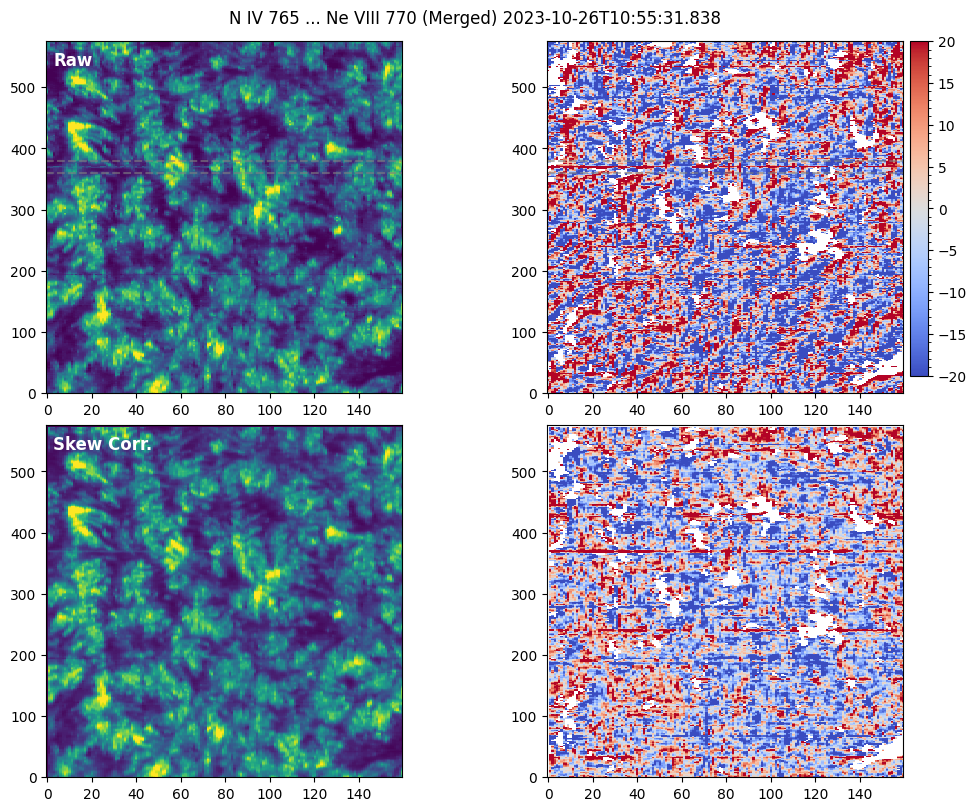

In [78]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,8), layout="constrained")

ax1.imshow(raw_NIV_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(raw_NIV_int, 0.5),
                               vmax=np.nanpercentile(raw_NIV_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im2 = ax2.imshow(raw_NIV_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax3.imshow(skew_NIV_int,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=np.nanpercentile(skew_NIV_int, 0.5),
                               vmax=np.nanpercentile(skew_NIV_int, 99.5),
                               stretch=AsinhStretch(0.1)))

im4 = ax4.imshow(skew_NIV_vel,
           origin="lower", aspect=spice_NeVIII_header['CDELT2']/spice_NeVIII_header['CDELT1'], interpolation='none',
           norm=ImageNormalize(vmin=-20, vmax=20), cmap="coolwarm")

ax1.text(0.02, 0.97, "Raw", transform=ax1.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

ax3.text(0.02, 0.97, "Skew Corr.", transform=ax3.transAxes, ha="left", va="top", weight="bold", fontsize=12,
        color="white")

clb, clb_ax = plot_colorbar(im2, ax2, bbox_to_anchor=[1.02, 0.05, 0.05, 0.95])

fig.suptitle(spice_NeVIII_header['EXTNAME'] + " " +spice_NeVIII_header['DATE-BEG'], fontsize=12)


for ax_ in (ax1,ax2):
    ax_.axhline(360, color="grey", alpha=0.6, ls="--")
    ax_.axhline(380, color="grey", alpha=0.6, ls="--")